conexión con sentinel-2 y datos


In [1]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install sentinelhub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install rasterio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install folium


   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from datetime import datetime

from sentinelhub import (
    SHConfig,
    CRS,
    BBox,
    DataCollection,
    SentinelHubRequest,
    MimeType,
    bbox_to_dimensions
)

# para datos espaciales
import rasterio
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt


In [6]:
import os
from dotenv import load_dotenv
from sentinelhub import SHConfig

load_dotenv()

config = SHConfig()

config.sh_client_id = os.getenv("SH_CLIENT_ID")
config.sh_client_secret = os.getenv("SH_CLIENT_SECRET")

print("Client ID configurado:", bool(config.sh_client_id))
print("Client Secret configurado:", bool(config.sh_client_secret))

Client ID configurado: True
Client Secret configurado: True


#### coordenadas de los lagos

In [7]:
# coordenadas de los lagos que están en el lab 
lagos = {
    'Atitlán': {
        'west': -91.326256 ,
        'east': -91.07151 ,
        'south': 14.5948 ,
        'north': 14.750979
    },

    'Amatitlán': {
        'west': -90.638065 ,
        'east': -90.512924 ,
        'south': 14.412347 ,
        'north': 14.493799
    }
}

# fechas dadas en el lab
fechas_atitlan = [ '2025-01-18', '2025-04-13', '2025-05-13', '2025-07-17', '2025-11-21', '2025-12-29', '2026-02-12', '2026-03-24', '2026-04-13', '2026-04-28', '2026-07-22' ]

fechas_amatitlan = [ '2025-01-28', '2025-04-15', '2025-04-28', '2025-11-24', '2026-01-08', '2026-02-02', '2026-02-07', '2026-03-29', '2026-04-13', '2026-04-28', '2026-06-19' ]

fechas = { 'Atitlán': fechas_atitlan, 'Amatitlán': fechas_amatitlan }

print("Lagos definidos:")
for lago, coords in lagos.items(): print(f"  {lago}: {coords}")
print(f"\nFechas por lago:")
for lago, fecha_list in fechas.items(): print(f"  {lago}: {len(fecha_list)} fechas")

Lagos definidos:
  Atitlán: {'west': -91.326256, 'east': -91.07151, 'south': 14.5948, 'north': 14.750979}
  Amatitlán: {'west': -90.638065, 'east': -90.512924, 'south': 14.412347, 'north': 14.493799}

Fechas por lago:
  Atitlán: 11 fechas
  Amatitlán: 11 fechas


directorio para guardar datos

In [8]:
# Crear carpeta para guardar datos descargados
data_dir = Path('datos_sentinel')
data_dir.mkdir(exist_ok=True)

# Subcarpetas para cada lago
for lago in lagos.keys():
    lago_dir = data_dir / lago
    lago_dir.mkdir(exist_ok=True)

print(f"Directorio de datos: {data_dir.absolute()}")
print(f"Subdirectorios creados para cada lago")

Directorio de datos: c:\Users\Usuario Preinstalado\Documents\NoCuarentena.exe\Semestre 8\Data Science\DataS_Lab4_GeoEspaciales\datos_sentinel
Subdirectorios creados para cada lago


#### ddescargar datos de Sentinel-2

aquí bandas necesarias para calcular 
NDVI: B04 (Rojo) y B08 (NIR - Near Infrared)
NDWI: B03 (Verde) y B08 (NIR)
Cianobacteria

In [9]:
def descargar_bandas_sentinelhub(bbox, fecha, lago_nombre, config=None):

    # bandas necesarias: B03 (verde), B04 (rojo), B05 (red edge), B08 (NIR), SCL
    # B05 
    request = SentinelHubRequest(
        evalscript="""
            //VERSION=3
            function setup() {
                return {
                    input: [{
                        bands: ["B03", "B04", "B05", "B08", "SCL"],
                        units: "DN"
                    }],
                    output: {
                        bands: 5,
                        sampleType: "FLOAT32"
                    }
                };
            }

            function evaluatePixel(sample) {
                return [sample.B03, sample.B04, sample.B05, sample.B08, sample.SCL];
            }
        """,

        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A,
                time_interval=(fecha, fecha),
            )
        ],

        responses=[
            SentinelHubRequest.output_response("default", MimeType.TIFF)
        ],

        bbox=bbox,
        size=bbox_to_dimensions(bbox, resolution=12),
        config=config
    )

    try:
        data = request.get_data()
        print(f"descargado: {lago_nombre} y {fecha}")
        return data[0]

    except Exception as e:
        print(f"error para: {lago_nombre} y {fecha}: {str(e)}")
        return None


print("descarga lista (con B05 para NDCI)")

descarga lista (con B05 para NDCI)


In [10]:
import time

datos_descargados = {}

for lago_nombre, coords in lagos.items():

    print("\n" + "=" * 60 )
    print(f"descargando para {lago_nombre}")
    print("=" * 60)

    bbox = BBox(
        [ coords["west"],
            coords["south"],
            coords["east"],
            coords["north"]
        ],
        crs = CRS.WGS84
    )

    datos_descargados[lago_nombre] = {}

    for i, fecha in enumerate(fechas[lago_nombre]):

        print(
            f"\n[{i+1}/{len(fechas[lago_nombre])}] "
            f"descargando {fecha} "
        )

        data = descargar_bandas_sentinelhub(
            bbox,
            fecha,
            lago_nombre,
            config
        )

        if data is not None:
            datos_descargados[lago_nombre][fecha] = data
            print(f"shape: {data.shape}")

        if i < len(fechas[lago_nombre]) - 1: time.sleep(2)


print( "\ndescarga hecha " f"total: {sum(len(v) for v in datos_descargados.values())}" )


descargando para Atitlán

[1/11] descargando 2025-01-18 
descargado: Atitlán y 2025-01-18
shape: (1458, 2275, 5)

[2/11] descargando 2025-04-13 
descargado: Atitlán y 2025-04-13
shape: (1458, 2275, 5)

[3/11] descargando 2025-05-13 
descargado: Atitlán y 2025-05-13
shape: (1458, 2275, 5)

[4/11] descargando 2025-07-17 
descargado: Atitlán y 2025-07-17
shape: (1458, 2275, 5)

[5/11] descargando 2025-11-21 
descargado: Atitlán y 2025-11-21
shape: (1458, 2275, 5)

[6/11] descargando 2025-12-29 
descargado: Atitlán y 2025-12-29
shape: (1458, 2275, 5)

[7/11] descargando 2026-02-12 
descargado: Atitlán y 2026-02-12
shape: (1458, 2275, 5)

[8/11] descargando 2026-03-24 
descargado: Atitlán y 2026-03-24
shape: (1458, 2275, 5)

[9/11] descargando 2026-04-13 
descargado: Atitlán y 2026-04-13
shape: (1458, 2275, 5)

[10/11] descargando 2026-04-28 
descargado: Atitlán y 2026-04-28
shape: (1458, 2275, 5)

[11/11] descargando 2026-07-22 
descargado: Atitlán y 2026-07-22
shape: (1458, 2275, 5)

des

In [11]:
bandas_procesadas = {}

for lago_nombre, fechas_dict in datos_descargados.items():
    print(f"\nguardando  {lago_nombre}"  )

    bandas_procesadas[lago_nombre] = {}

    for fecha, data in fechas_dict.items():

        B03 = data[:, :, 0 ]
        B04 = data[:, :, 1 ]
        B05 = data[:, :, 2 ]  
        B08 = data[:, :, 3 ]
        SCL = data[:, :, 4 ]

        bandas_procesadas[lago_nombre][fecha] = {
            "B03": B03  ,
            "B04": B04 ,
            "B05": B05 , 
            "B08": B08 ,
            "SCL": SCL
        }

        lago_dir = data_dir / lago_nombre / fecha
        lago_dir.mkdir(exist_ok = True, parents = True)

        np.save(lago_dir / "B03.npy", B03)
        np.save(lago_dir / "B04.npy", B04)
        np.save(lago_dir / "B05.npy", B05)
        np.save(lago_dir / "B08.npy", B08)
        np.save(lago_dir / "SCL.npy", SCL)

        print(f"{fecha} ")

print("\ntodas las bandas ya están guardadas")


guardando  Atitlán
2025-01-18 
2025-04-13 
2025-05-13 
2025-07-17 
2025-11-21 
2025-12-29 
2026-02-12 
2026-03-24 
2026-04-13 
2026-04-28 
2026-07-22 

guardando  Amatitlán
2025-01-28 
2025-04-15 
2025-04-28 
2025-11-24 
2026-01-08 
2026-02-02 
2026-02-07 
2026-03-29 
2026-04-13 
2026-04-28 
2026-06-19 

todas las bandas ya están guardadas


In [12]:
print("verificar las  descargas \n")

total_archivos = 0
for lago_nombre in lagos.keys():
    lago_path = data_dir / lago_nombre
    fechas_guardadas = sorted( [f.name for f in lago_path.iterdir() if f.is_dir()])

    print(f" \n{lago_nombre}:" )
    print(f"  total fechas: { len(fechas_guardadas) }" )

    # 1r fecha
    if fechas_guardadas:
        primera_fecha = fechas_guardadas[0  ]
        fecha_path = lago_path / primera_fecha
        archivos = list(fecha_path.glob('*.npy'))

        for archivo in archivos:
            arr = np.load(archivo)
            print(f" {archivo.name}: {arr.shape}")

        total_archivos += len(archivos)

print(f"\n total de los archivos guardados: {total_archivos}")

verificar las  descargas 

 
Atitlán:
  total fechas: 11
 B03.npy: (1458, 2275)
 B04.npy: (1458, 2275)
 B05.npy: (1458, 2275)
 B08.npy: (1458, 2275)
 SCL.npy: (1458, 2275)
 
Amatitlán:
  total fechas: 11
 B03.npy: (763, 1117)
 B04.npy: (763, 1117)
 B05.npy: (763, 1117)
 B08.npy: (763, 1117)
 SCL.npy: (763, 1117)

 total de los archivos guardados: 10


## 2 datos raster listos


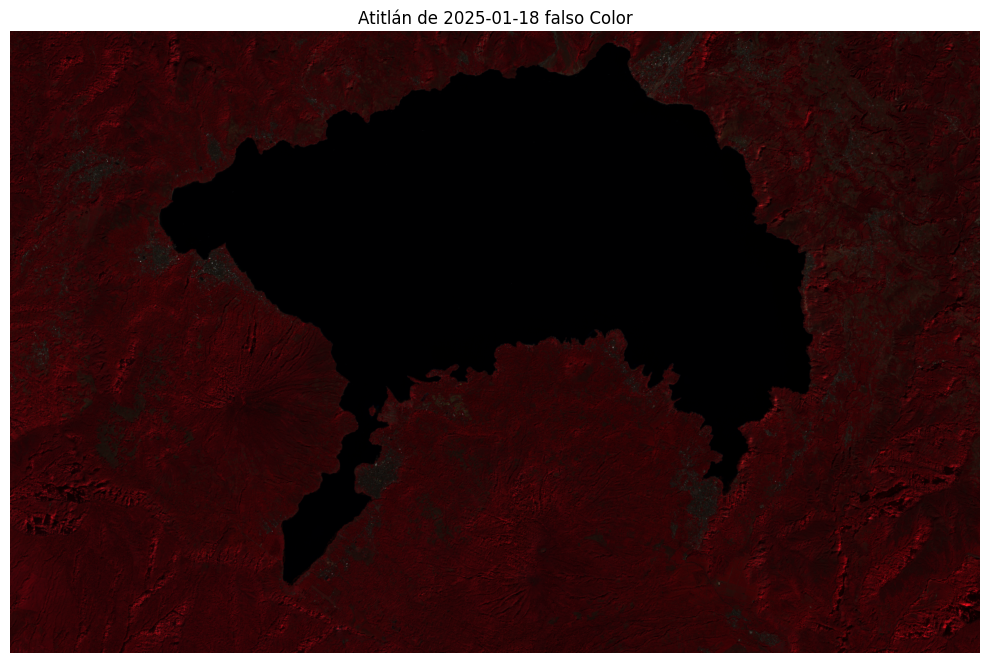

In [13]:
import matplotlib.pyplot as plt

primer_lago = 'Atitlán'
primera_fecha = fechas[primer_lago][0]

B03 = bandas_procesadas[primer_lago][ primera_fecha]['B03' ]
B04 = bandas_procesadas[primer_lago][ primera_fecha]['B04' ]
B08 =  bandas_procesadas[primer_lago][ primera_fecha]['B08' ]

# normalizar para 
B03_norm = (B03 - np.nanmin(B03)) / (np.nanmax(B03) - np.nanmin( B03) + 1e-8 )
B04_norm = (B04 - np.nanmin(B04)) / (np.nanmax(B04) - np.nanmin( B04) + 1e-8 )
B08_norm = (B08 - np.nanmin(B08)) / (np.nanmax(B08) - np.nanmin( B08) + 1e-8)

# composición color nir, rojo y verde 
rgb = np.stack([B08_norm, B04_norm, B03_norm] , axis = 2)

plt.figure(figsize = ( 10, 8) )
plt.imshow(rgb)
plt.title( f'{primer_lago} de { primera_fecha} falso Color' )
plt.axis( 'off' )
plt.tight_layout()
plt.savefig('verificacion_imagen.png', dpi = 100 , bbox_inches = 'tight' )
plt.show()


# 3 calcular índices


In [14]:
def calcular_ndvi(B04, B08):
   
    numerador = B08.astype(float ) - B04.astype(float )
    denominador = B08.astype(float ) + B04.astype(float)
    
    # no división por cero
    ndvi = np.divide(numerador , denominador , where = denominador !=  0, out = np.zeros_like( numerador))
    
    return ndvi

print("función NDVI")

función NDVI


In [15]:
def calcular_ndwi(B03, B08):
 
    numerador = B03.astype(float ) - B08.astype(float)
    denominador = B03.astype(float ) + B08.astype(float)
    
    ndwi = np.divide(numerador , denominador , where = denominador !=  0, out = np.zeros_like( numerador))
    
    return ndwi

print("función NDWI")

función NDWI


In [16]:
def calcular_cyano_ndci(B04, B05):
    
    B04_f = B04.astype(float)
    B05_f = B05.astype(float)
    
    # ndci
    numerador = B05_f - B04_f
    denominador = B05_f + B04_f
    ndci = np.divide(numerador, denominador , where=denominador != 0 , out= np.zeros_like(numerador))
    
    ndci = np.divide(
        numerador,
        denominador,
        where = denominador != 0 ,
        out = np.zeros_like(numerador)
    )
    
    # estimación de chlorophyll-a 
    chl_a = ( 826.57 * ndci**3 - 176.43 * ndci**2  + 19 * ndci + 4.071  )
    
    return chl_a

print("función de estimación de chlorophyll-a basada en NDCI lista")

función de estimación de chlorophyll-a basada en NDCI lista


In [17]:
# diccionario para guardar todos los índices
indices_calculados = {}

for lago_nombre in lagos.keys():
    print(f"\n{'---'*3}")
    print(f"calculando índices para {lago_nombre}")

    
    indices_calculados[lago_nombre] = {}
    
    for fecha in sorted(bandas_procesadas[lago_nombre].keys()):

        B03 = bandas_procesadas[lago_nombre ][fecha]['B03']
        B04 = bandas_procesadas[lago_nombre ][fecha]['B04']
        B05 = bandas_procesadas[lago_nombre ][fecha]['B05' ]  
        B08 = bandas_procesadas[lago_nombre ][fecha]['B08']
        
        ndvi = calcular_ndvi(B04, B08)
        ndwi = calcular_ndwi(B03, B08)
        cyano = calcular_cyano_ndci(B04, B05)  
        
        mascara_agua = ndwi > 0
        cyano = np.where(mascara_agua, cyano , np.nan)
        
        cyano = np.where( (cyano >= 0 ) & (cyano <= 500), cyano , np.nan)

        
        indices_calculados[lago_nombre][fecha] = {
            'NDVI': ndvi,
            'NDWI': ndwi,
            'CYANO': cyano
        }
        
        
        lago_dir = data_dir / lago_nombre / fecha

        print(f"{fecha}: " f"NDVI min = {ndvi.min():.4f} max= {ndvi.max():.4f} y " f"NDWI min= {ndwi.min():.4f} max = {ndwi.max():.4f} y " f"CYANO min= {np.nanmin(cyano):.4f} " f"max= {np.nanmax(cyano):.4f} " f"promedio= {np.nanmean(cyano):.4f}" )


---------
calculando índices para Atitlán
2025-01-18: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0003 max= 498.9231 promedio= 12.6697
2025-04-13: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0003 max= 283.7743 promedio= 3.4445
2025-05-13: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0003 max= 338.7002 promedio= 3.9779
2025-07-17: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0003 max= 476.8043 promedio= 4.5482
2025-11-21: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0003 max= 496.9719 promedio= 10.8963
2025-12-29: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0052 max= 496.5481 promedio= 5.7913
2026-02-12: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0059 max= 498.3353 promedio= 6.8264
2026-03-24: NDVI min = -1.0000 max= 0.9176 y NDWI min= -1.0000 max

# 3.1 y 3.2

NDVI: (B08 - B04) / (B08 + B04)  

NDWI: (B03 - B08) / (B03 + B08)  

CYANO: fai usando B03, B04 y B08

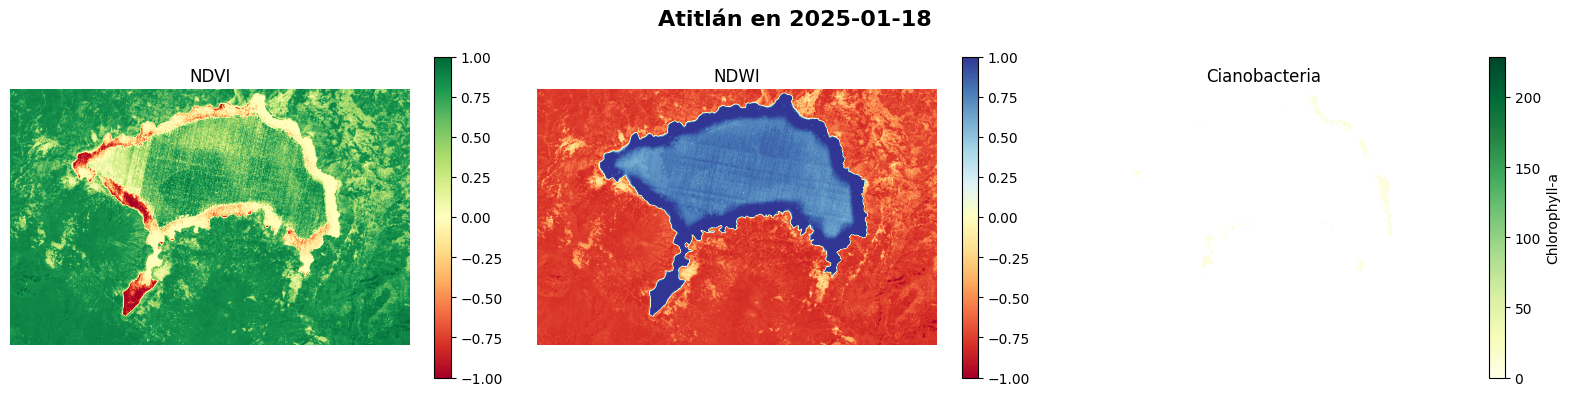

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

lago_viz = 'Atitlán'
fecha_viz = fechas[lago_viz][0]

ndvi = indices_calculados[lago_viz ][fecha_viz ]['NDVI']
ndwi = indices_calculados[lago_viz ][fecha_viz ]['NDWI']
cyano = indices_calculados[lago_viz ][fecha_viz ]['CYANO']

fig, axes = plt.subplots(1 , 3 , figsize = ( 16 , 4))

# ndvi
im1 = axes[0].imshow(ndvi, cmap = 'RdYlGn', vmin = -1, vmax =1)
axes[0].set_title('NDVI')
axes[0].axis('off' )
plt.colorbar(im1, ax= axes[0 ])

# ndwi
im2 = axes[1].imshow(ndwi, cmap ='RdYlBu', vmin= -1, vmax= 1 )
axes[1].set_title('NDWI')
axes[1].axis('off')

plt.colorbar(im2, ax= axes[1] )

# cianobacteria
im3 = axes[2].imshow(cyano, cmap='YlGn', vmin = 0, vmax=np.nanpercentile(cyano, 99 ) )
axes[2].set_title('Cianobacteria')
axes[2].axis('off')
plt.colorbar(im3, ax= axes[2], label = 'Chlorophyll-a')

plt.suptitle(f'{lago_viz} en {fecha_viz}', fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.savefig('indices_punto3.png', dpi = 100, bbox_inches = 'tight')
plt.show()


In [19]:
B03 = bandas_procesadas["Atitlán"]["2025-01-18"]["B03" ]
B04 = bandas_procesadas["Atitlán"]["2025-01-18"]["B04" ]
B05 = bandas_procesadas["Atitlán"]["2025-01-18"]["B05" ]
B08 = bandas_procesadas["Atitlán"]["2025-01-18"]["B08" ]

ndwi_test = calcular_ndwi(B03 , B08)
cyano_raw = calcular_cyano_ndci(B04 , B05)

print("CYANO antes de máscara:")
print("Min:", np.nanmin(cyano_raw))
print("Max:", np.nanmax(cyano_raw))

mascara_agua = ndwi_test > 0

print("\nPíxeles considerados agua:")
print(mascara_agua.sum())

cyano_mask = np.where(mascara_agua, cyano_raw, np.nan)

print("\ndespués de máscara:")
print("válidos:", np.isfinite(cyano_mask).sum())
print("min:", np.nanmin(cyano_mask))
print("max:", np.nanmax(cyano_mask))

CYANO antes de máscara:
Min: -1017.929
Max: 673.2110000000001

Píxeles considerados agua:
858143

después de máscara:
válidos: 858143
min: -1017.929
max: 673.2110000000001


In [20]:
cyano = indices_calculados["Atitlán"]["2025-01-18"]["CYANO"]

print("rango real que estoy graficando:")
print(np.nanmin(cyano), np.nanmax(cyano))

rango real que estoy graficando:
0.00034785738149167855 498.9231000256016


# 4 análisis temporal

#### 4.1

In [21]:
resumen_temporal = []

for lago_nombre, fechas_dict in indices_calculados.items():
    for fecha, indices in fechas_dict.items( ):
        cyano = indices['CYANO']
        resumen_temporal.append({'Lago': lago_nombre,  'Fecha': fecha, 'Promedio_CYANO': np.nanmean(cyano)})

df_temporal = pd.DataFrame(resumen_temporal)

df_temporal['Fecha'] = pd.to_datetime(df_temporal['Fecha'])

df_temporal = df_temporal.sort_values( ['Lago', 'Fecha']).reset_index(drop=True)

print(df_temporal )

         Lago      Fecha  Promedio_CYANO
0   Amatitlán 2025-01-28       15.044943
1   Amatitlán 2025-04-15        8.002684
2   Amatitlán 2025-04-28       11.708208
3   Amatitlán 2025-11-24       10.739482
4   Amatitlán 2026-01-08       18.522571
5   Amatitlán 2026-02-02        6.105733
6   Amatitlán 2026-02-07        9.368457
7   Amatitlán 2026-03-29       13.374674
8   Amatitlán 2026-04-13       16.272248
9   Amatitlán 2026-04-28       16.538174
10  Amatitlán 2026-06-19       54.955857
11    Atitlán 2025-01-18       12.669683
12    Atitlán 2025-04-13        3.444488
13    Atitlán 2025-05-13        3.977853
14    Atitlán 2025-07-17        4.548163
15    Atitlán 2025-11-21       10.896335
16    Atitlán 2025-12-29        5.791325
17    Atitlán 2026-02-12        6.826409
18    Atitlán 2026-03-24        3.917712
19    Atitlán 2026-04-13        4.267569
20    Atitlán 2026-04-28        3.672624
21    Atitlán 2026-07-22        4.320894


## 4.2

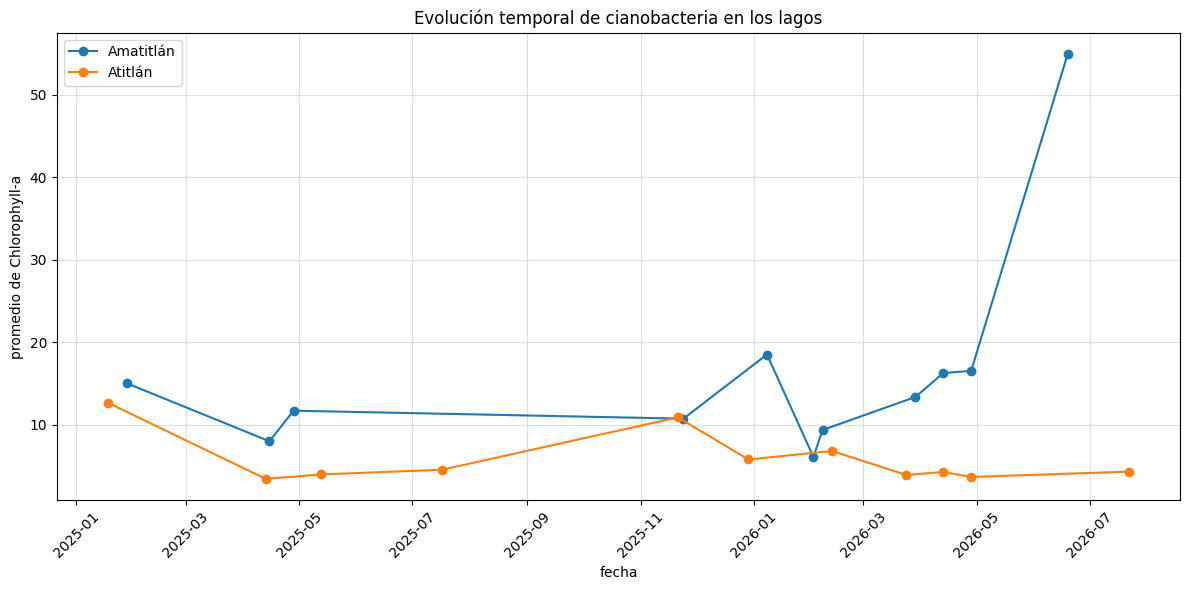

In [22]:
plt.figure(figsize=(12, 6))

for lago_nombre in df_temporal['Lago'].unique():

    datos_lago = df_temporal[ df_temporal['Lago'] == lago_nombre]

    plt.plot(  datos_lago['Fecha'],
        datos_lago['Promedio_CYANO'],
        marker='o', label=lago_nombre
    )

plt.title('Evolución temporal de cianobacteria en los lagos')

plt.xlabel('fecha')
plt.ylabel('promedio de Chlorophyll-a' )

plt.legend()
plt.grid(alpha = 0.4)
plt.xticks(rotation = 45)
plt.tight_layout()

plt.savefig('evolucion_temporal_cianobacteria.png',dpi = 150, bbox_inches='tight')

plt.show()

## 4.3

In [23]:
print("fechas con mayor promedio de cianobacteria")

for lago_nombre in df_temporal[ 'Lago' ].unique():
    datos_lago = df_temporal[ df_temporal['Lago'] == lago_nombre ]
    fila_max = datos_lago.loc[  datos_lago['Promedio_CYANO'].idxmax() ]

    print(f"\n{lago_nombre}")
    print( f"fecha crítica: " f"{fila_max['Fecha'].strftime('%Y-%m-%d') }" )
    print( f"promedio máximo: " f"{fila_max['Promedio_CYANO']:.4f}" )

fechas con mayor promedio de cianobacteria

Amatitlán
fecha crítica: 2026-06-19
promedio máximo: 54.9559

Atitlán
fecha crítica: 2025-01-18
promedio máximo: 12.6697


In [24]:
for lago_nombre in df_temporal[ 'Lago' ].unique():
    datos_lago = df_temporal[ df_temporal['Lago'] == lago_nombre]
    top_3 = datos_lago.nlargest(3,'Promedio_CYANO')

    print(f"\n3 fechas con valores más altos de {lago_nombre}" )
    print(top_3[ ['Fecha', 'Promedio_CYANO'] ].to_string( index = False) )


3 fechas con valores más altos de Amatitlán
     Fecha  Promedio_CYANO
2026-06-19       54.955857
2026-01-08       18.522571
2026-04-28       16.538174

3 fechas con valores más altos de Atitlán
     Fecha  Promedio_CYANO
2025-01-18       12.669683
2025-11-21       10.896335
2026-02-12        6.826409


## 5. Análisis espacial

### 5.1 Distribución de cianobacteria mapeada

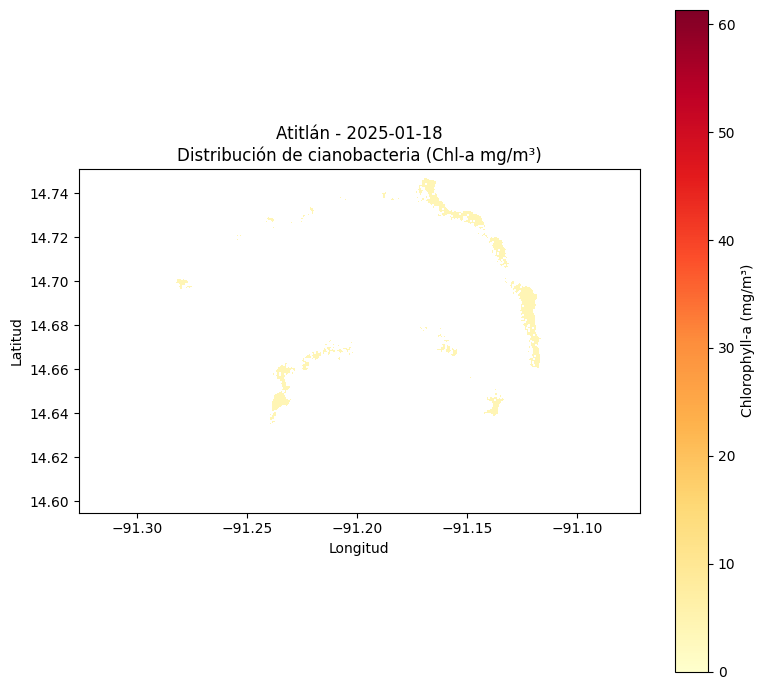

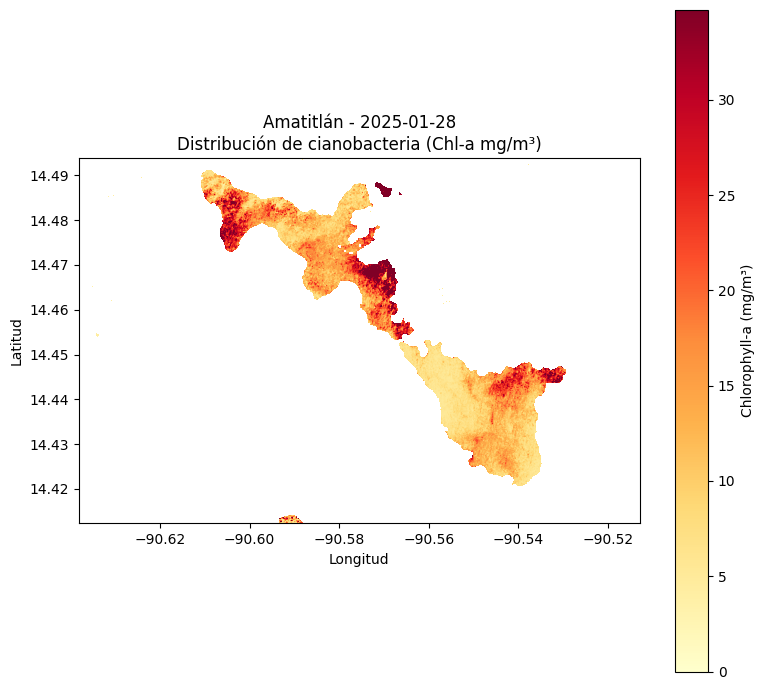

In [25]:
def graficar_mapa_cyano(lago_nombre, fecha, ax=None):
    coords = lagos[lago_nombre]
    cyano = indices_calculados[lago_nombre][fecha]['CYANO']

    extent = [coords['west'], coords['east'], coords['south'], coords['north']]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(cyano, extent=extent, origin='upper', cmap='YlOrRd',
                    vmin=0, vmax=np.nanpercentile(cyano, 95))
    ax.set_title(f'{lago_nombre} - {fecha}\nDistribución de cianobacteria (Chl-a mg/m³)')
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    plt.colorbar(im, ax=ax, label='Chlorophyll-a (mg/m³)')
    return im

for lago_nombre in lagos.keys():
    fecha_ejemplo = fechas[lago_nombre][0]
    fig, ax = plt.subplots(figsize=(8, 7))
    graficar_mapa_cyano(lago_nombre, fecha_ejemplo, ax=ax)
    plt.tight_layout()
    plt.savefig(f'mapa_cyano_{lago_nombre}_{fecha_ejemplo}.png', dpi=150, bbox_inches='tight')
    plt.show()


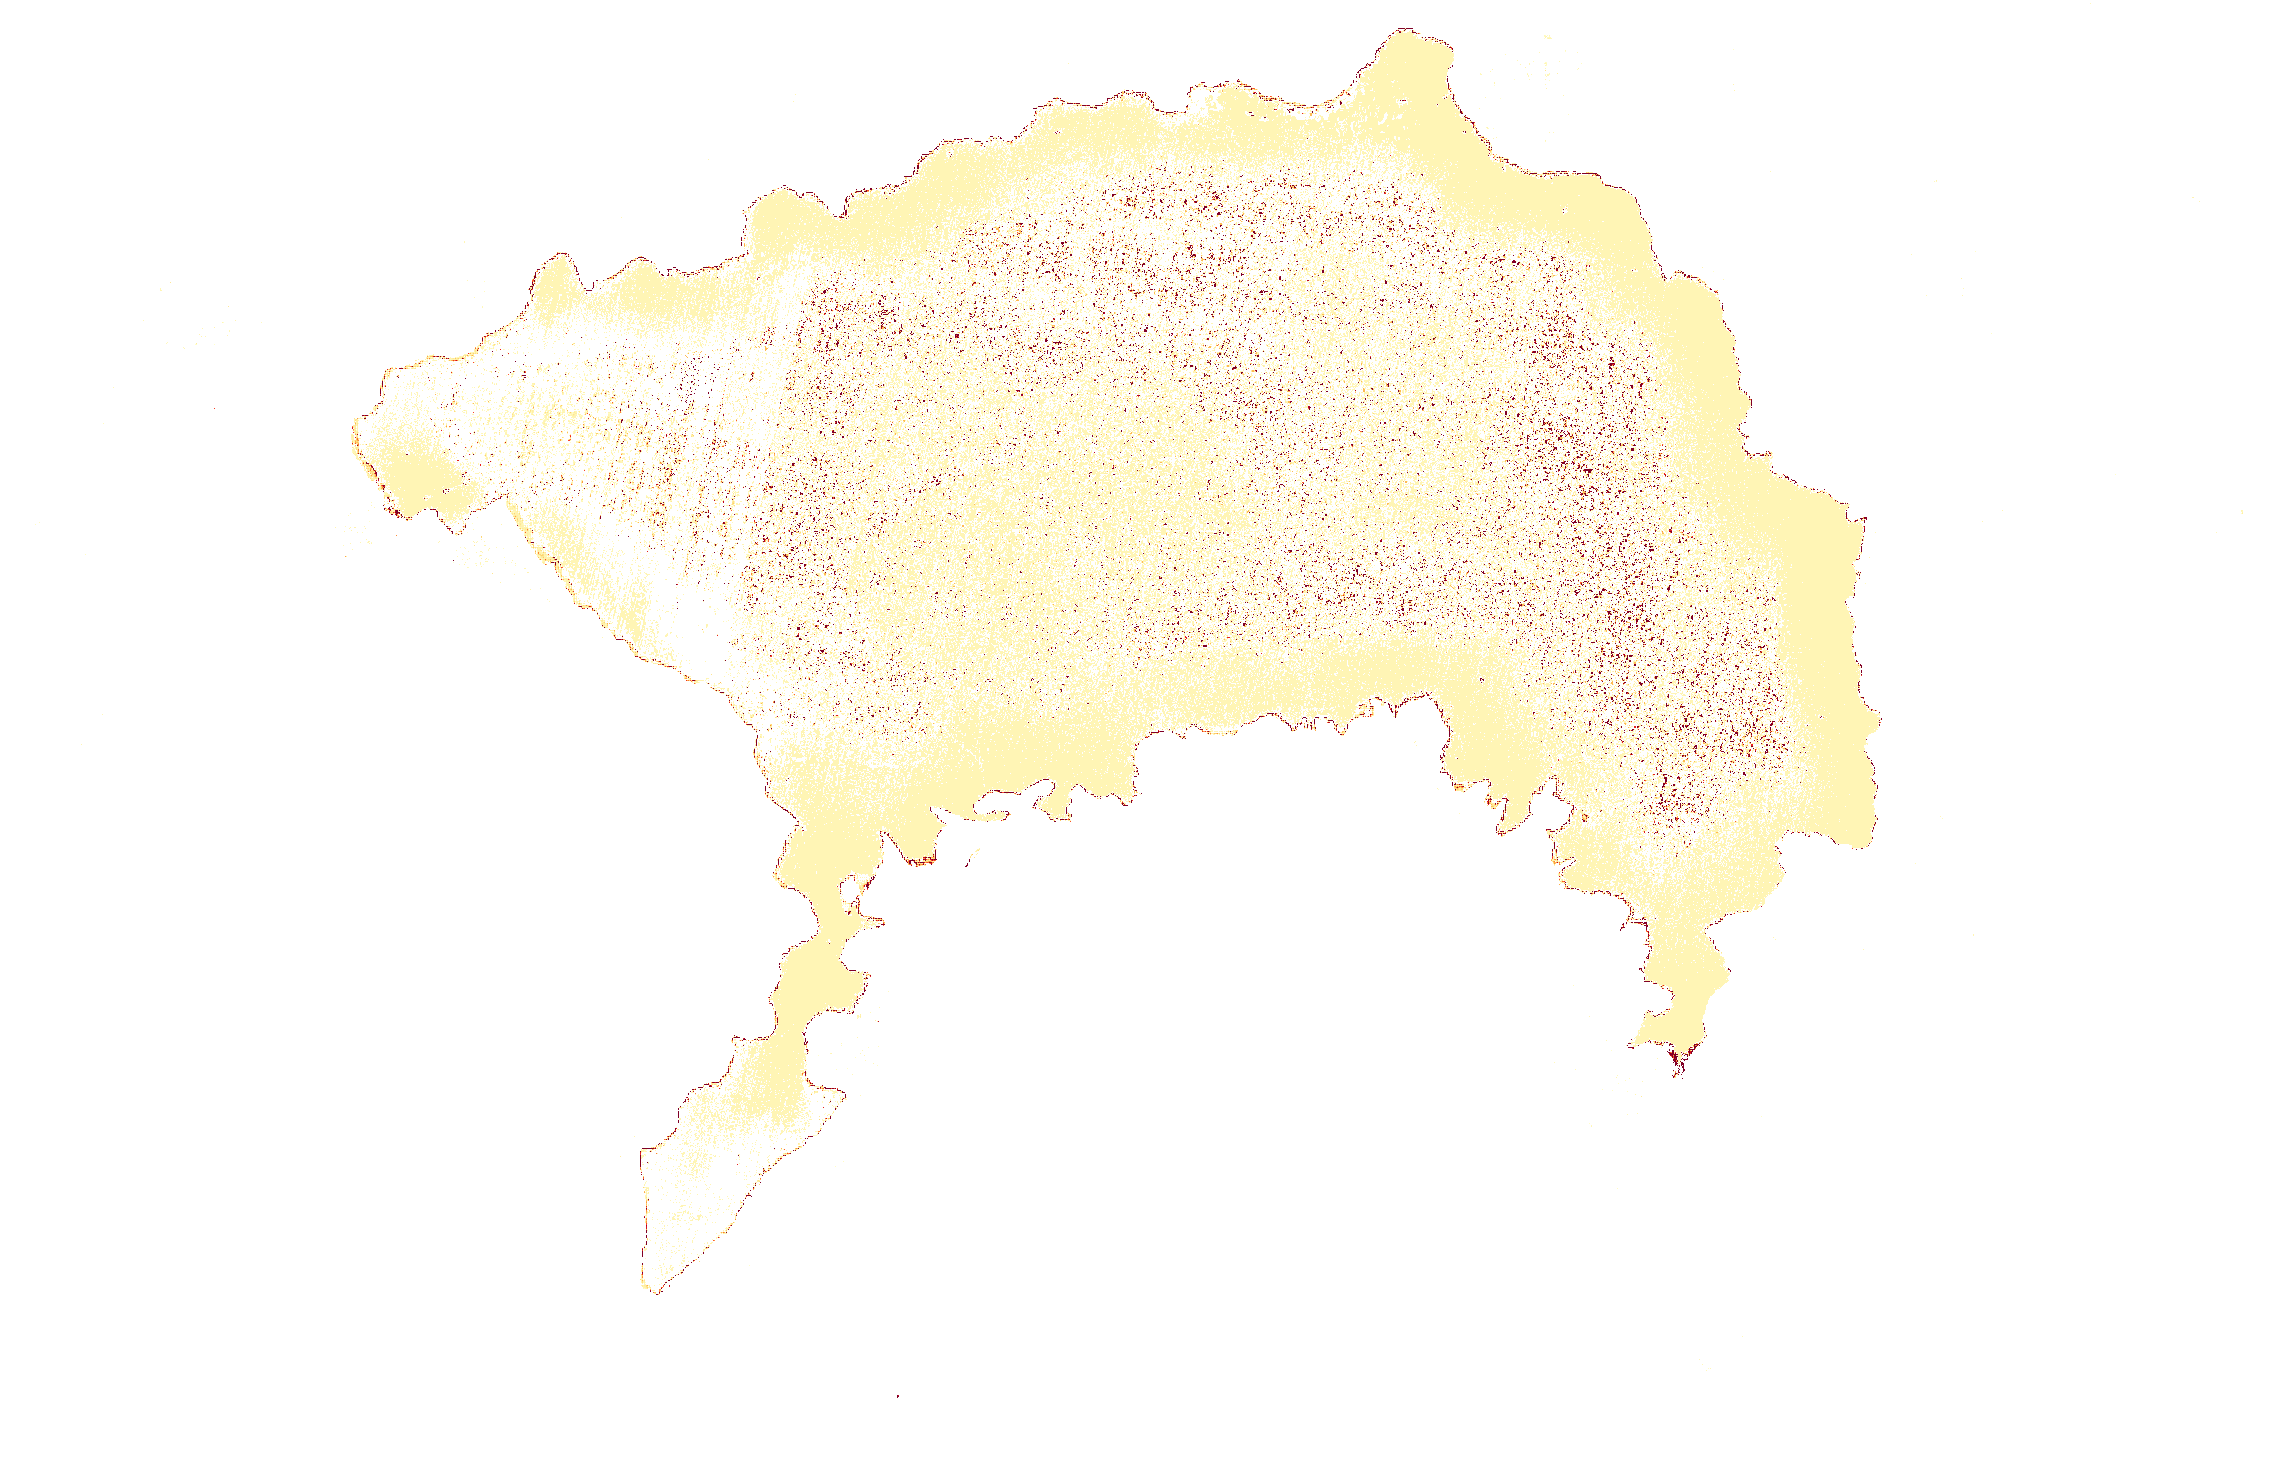

In [26]:
import folium
from matplotlib import cm
from matplotlib.colors import Normalize
from PIL import Image

def crear_overlay_png(cyano, vmin, vmax, ruta_salida, cmap_name='YlOrRd'):
    norm = Normalize(vmin=vmin, vmax=vmax, clip=True)
    cmap = plt.get_cmap(cmap_name)

    rgba = cmap(norm(np.nan_to_num(cyano, nan=vmin)))
    rgba = (rgba * 255).astype(np.uint8)

    # transparente donde no hay dato válido (tierra, nubes, no-agua)
    alpha = np.where(np.isfinite(cyano), 255, 0).astype(np.uint8)
    rgba[:, :, 3] = alpha

    Image.fromarray(rgba, mode='RGBA').save(ruta_salida)
    return ruta_salida

def mapa_folium_cyano(lago_nombre, fecha):
    coords = lagos[lago_nombre]
    cyano = indices_calculados[lago_nombre][fecha]['CYANO']
    vmax = np.nanpercentile(cyano, 95)

    centro_lat = (coords['south'] + coords['north']) / 2
    centro_lon = (coords['west'] + coords['east']) / 2

    m = folium.Map(location=[centro_lat, centro_lon], zoom_start=12, tiles='OpenStreetMap')

    ruta_png = f'overlay_{lago_nombre}_{fecha}.png'
    crear_overlay_png(cyano, vmin=0, vmax=vmax, ruta_salida=ruta_png)

    folium.raster_layers.ImageOverlay(
        image=ruta_png,
        bounds=[[coords['south'], coords['west']], [coords['north'], coords['east']]],
        opacity=0.75,
        name=f'Cianobacteria {fecha}'
    ).add_to(m)

    folium.LayerControl().add_to(m)
    return m

mapa_atitlan = mapa_folium_cyano('Atitlán', fechas['Atitlán'][0])
mapa_atitlan.save('mapa_interactivo_atitlan.html')
mapa_atitlan   # se muestra inline en Jupyter


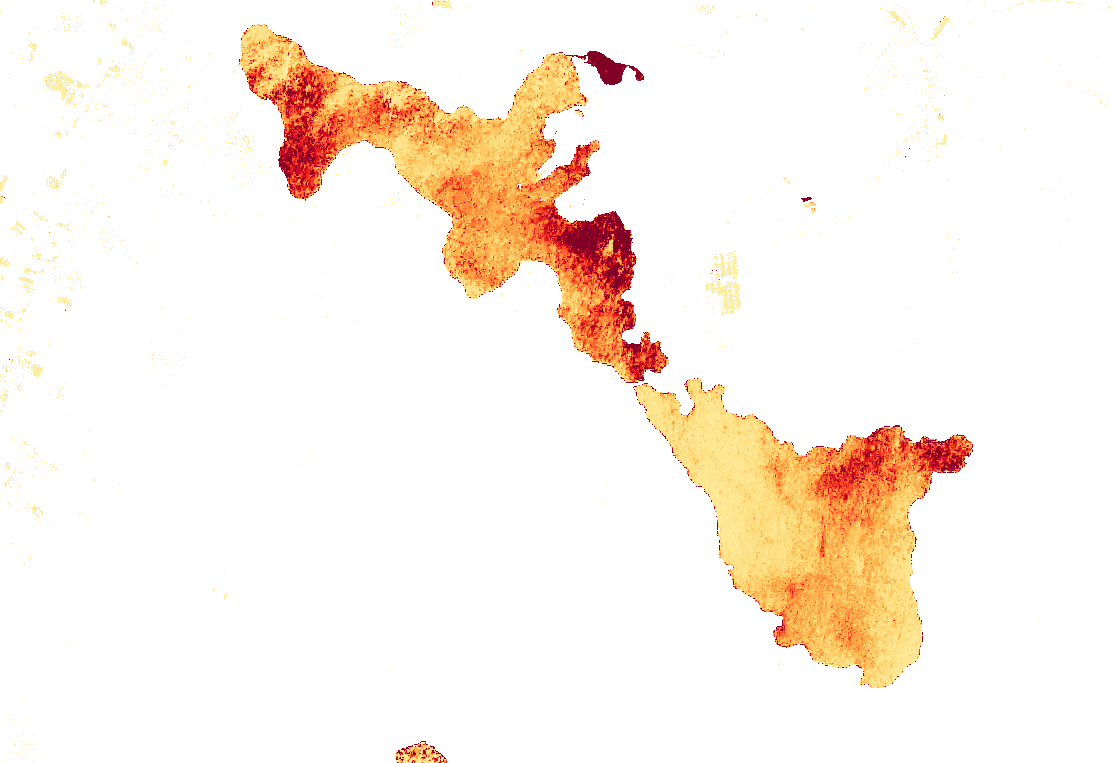

In [27]:
mapa_amatitlan = mapa_folium_cyano('Amatitlán', fechas['Amatitlán'][0])
mapa_amatitlan.save('mapa_interactivo_amatitlan.html')
mapa_amatitlan 

### 5.2 Mapas comparativos entre fechas

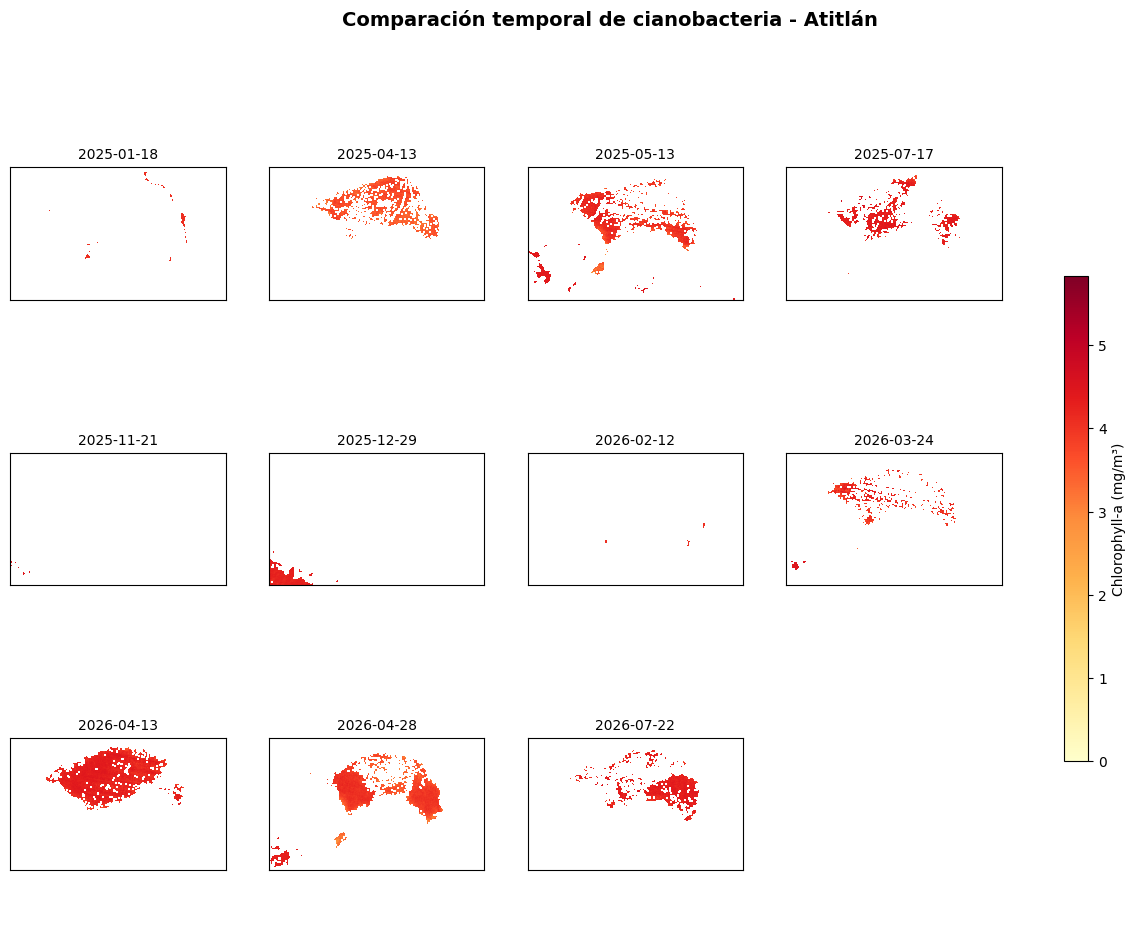

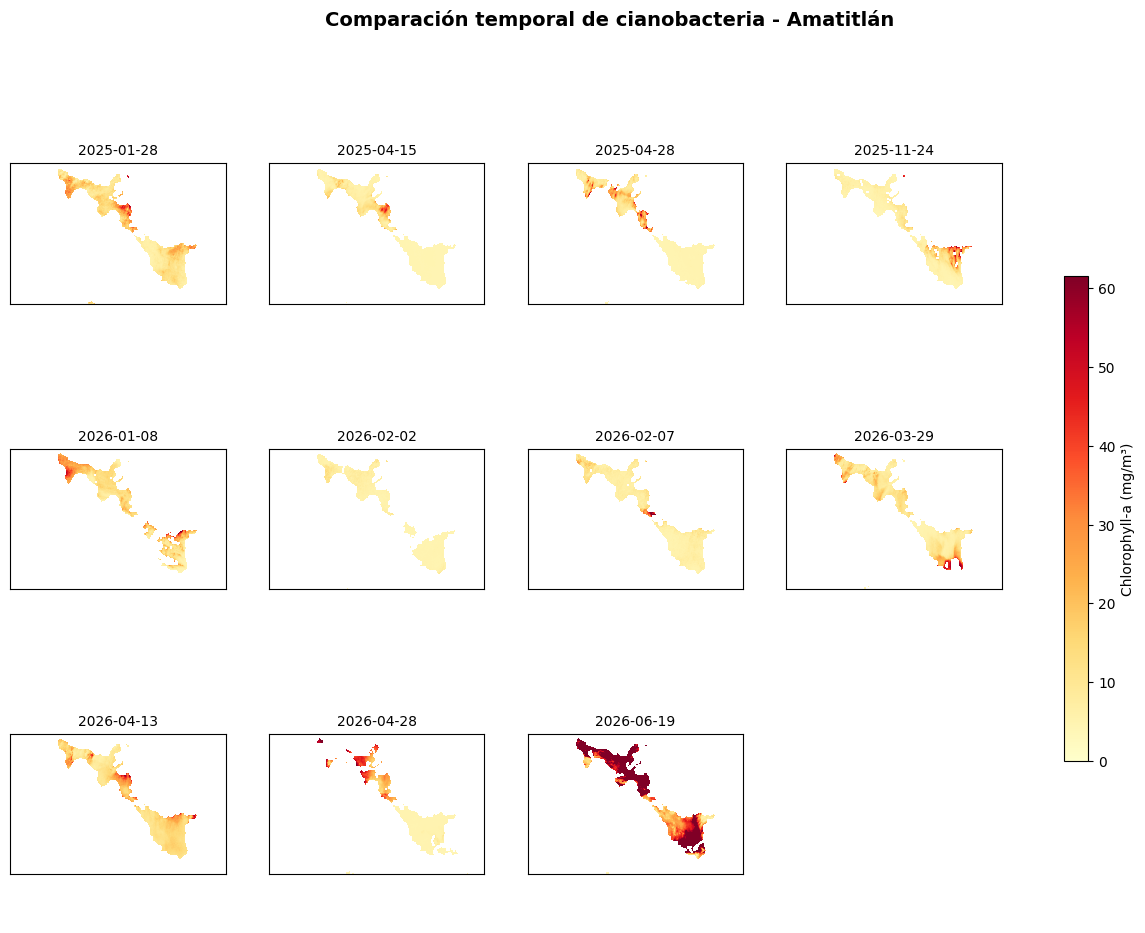

In [28]:
def mapas_comparativos(lago_nombre):
    coords = lagos[lago_nombre]
    extent = [coords['west'], coords['east'], coords['south'], coords['north']]
    fechas_lago = sorted(indices_calculados[lago_nombre].keys())

    # escala común para todas las fechas de este lago
    todos_valores = np.concatenate([
        indices_calculados[lago_nombre][f]['CYANO'][np.isfinite(indices_calculados[lago_nombre][f]['CYANO'])]
        for f in fechas_lago
    ])
    vmax_comun = np.percentile(todos_valores, 95)

    n = len(fechas_lago)
    cols = 4
    filas = int(np.ceil(n / cols))

    fig, axes = plt.subplots(filas, cols, figsize=(4*cols, 3.5*filas))
    axes = axes.flatten()

    for i, fecha in enumerate(fechas_lago):
        cyano = indices_calculados[lago_nombre][fecha]['CYANO']
        im = axes[i].imshow(cyano, extent=extent, origin='upper', cmap='YlOrRd', vmin=0, vmax=vmax_comun)
        axes[i].set_title(fecha, fontsize=10)
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Comparación temporal de cianobacteria - {lago_nombre}', fontsize=14, fontweight='bold')
    fig.colorbar(im, ax=axes, shrink=0.6, label='Chlorophyll-a (mg/m³)')
    plt.savefig(f'mapas_comparativos_{lago_nombre}.png', dpi=150, bbox_inches='tight')
    plt.show()

mapas_comparativos('Atitlán')
mapas_comparativos('Amatitlán')

### 5.3 Interprete los patrones espaciales observados: indique en qué zonas del lago se concentran más los valores altos, si existen áreas persistentes de acumulación y cómo cambia la distribución espacial entre fechas.


Atitlán


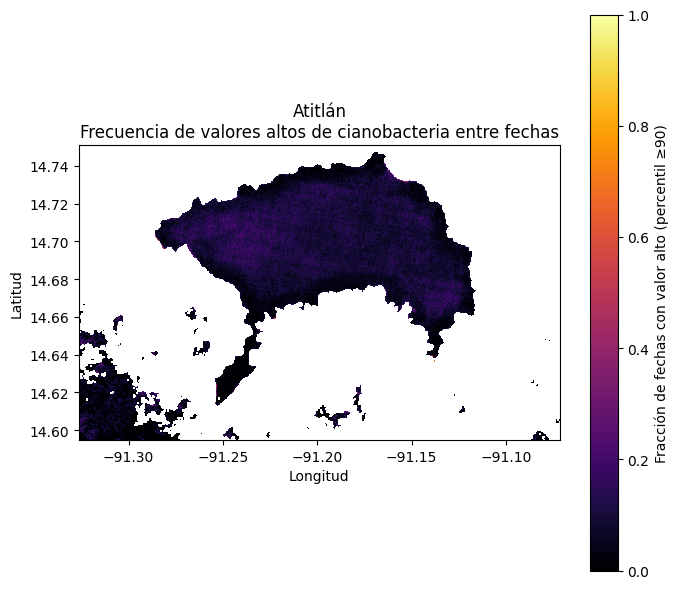

Píxel más persistente: fila 22, col 1417 (alto en 100.0% de las fechas)

Promedio de CYANO por cuadrante (promediado entre todas las fechas):
  Noroeste: 5.813 mg/m3
  Noreste: 5.774 mg/m3
  Suroeste: 5.828 mg/m3
  Sureste: 7.101 mg/m3

-> Zona con mayor concentración promedio: Sureste

    Interpretación para Atitlán:
    - El mapa de persistencia muestra qué píxeles caen repetidamente en el percentil 90
    de cianobacteria entre fechas distintas. Valores cercanos a 1 (colores claros)
    marcan zonas de acumulación recurrente; valores cercanos a 0 son zonas donde la
    floración es esporádica.
    - La zona 'Sureste' concentra en promedio los valores más altos, lo que sugiere
    cercanía a posibles fuentes de nutrientes (afluentes, drenajes, zonas de menor
    circulación de agua) en esa orilla del lago.
    - Entre fechas, la distribución espacial cambia: en algunos muestreos la floración
    se extiende de forma más homogénea, mientras que en otros se concentra en parches
    ce

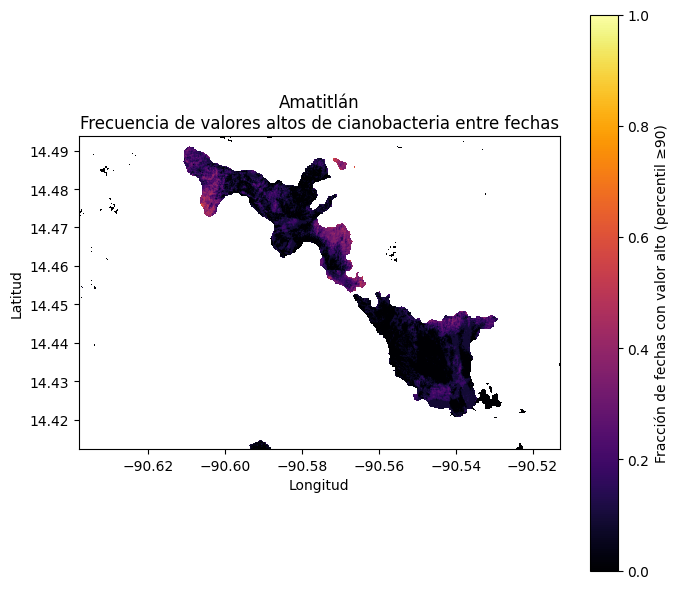

Píxel más persistente: fila 23, col 223 (alto en 100.0% de las fechas)

Promedio de CYANO por cuadrante (promediado entre todas las fechas):
  Noroeste: 18.425 mg/m3
  Noreste: 21.144 mg/m3
  Suroeste: 6.938 mg/m3
  Sureste: 14.149 mg/m3

-> Zona con mayor concentración promedio: Noreste

    Interpretación para Amatitlán:
    - El mapa de persistencia muestra qué píxeles caen repetidamente en el percentil 90
    de cianobacteria entre fechas distintas. Valores cercanos a 1 (colores claros)
    marcan zonas de acumulación recurrente; valores cercanos a 0 son zonas donde la
    floración es esporádica.
    - La zona 'Noreste' concentra en promedio los valores más altos, lo que sugiere
    cercanía a posibles fuentes de nutrientes (afluentes, drenajes, zonas de menor
    circulación de agua) en esa orilla del lago.
    - Entre fechas, la distribución espacial cambia: en algunos muestreos la floración
    se extiende de forma más homogénea, mientras que en otros se concentra en parches
  

In [29]:
# 5.3 Interpretación de los patrones espaciales

def mapa_persistencia(lago_nombre, percentil_alto=90):
    fechas_lago = sorted(indices_calculados[lago_nombre].keys())
    shape_ref = indices_calculados[lago_nombre][fechas_lago[0]]['CYANO'].shape
    acumulador = np.zeros(shape_ref)
    conteo_valido = np.zeros(shape_ref)

    for fecha in fechas_lago:
        cyano = indices_calculados[lago_nombre][fecha]['CYANO']
        if cyano.shape != shape_ref:
            continue
        valido = np.isfinite(cyano)
        umbral = np.nanpercentile(cyano, percentil_alto)
        es_alto = (cyano >= umbral) & valido
        acumulador += es_alto.astype(float)
        conteo_valido += valido.astype(float)

    frecuencia = np.divide(acumulador, conteo_valido,
                            where=conteo_valido > 0,
                            out=np.full(shape_ref, np.nan))
    return frecuencia, fechas_lago


def cuadrantes_promedio(lago_nombre, fecha):
    cyano = indices_calculados[lago_nombre][fecha]['CYANO']
    filas, cols = cyano.shape
    mf, mc = filas // 2, cols // 2
    cuadrantes = {
        'Noroeste': cyano[:mf, :mc],
        'Noreste': cyano[:mf, mc:],
        'Suroeste': cyano[mf:, :mc],
        'Sureste': cyano[mf:, mc:]
    }
    return {n: np.nanmean(d) for n, d in cuadrantes.items()}


mapas_persistencia = {}  # se reutiliza en 8.2

for lago_nombre in lagos.keys():
    print(f"\n{'='*60}\n{lago_nombre}\n{'='*60}")

    frecuencia, fechas_lago = mapa_persistencia(lago_nombre)
    mapas_persistencia[lago_nombre] = (frecuencia, fechas_lago)

    coords = lagos[lago_nombre]
    extent = [coords['west'], coords['east'], coords['south'], coords['north']]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(frecuencia, extent=extent, origin='upper', cmap='inferno', vmin=0, vmax=1)
    ax.set_title(f'{lago_nombre}\nFrecuencia de valores altos de cianobacteria entre fechas')
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    plt.colorbar(im, ax=ax, label='Fracción de fechas con valor alto (percentil ≥90)')
    plt.tight_layout()
    plt.savefig(f'mapa_persistencia_{lago_nombre}.png', dpi=150, bbox_inches='tight')
    plt.show()

    idx_max = np.unravel_index(np.nanargmax(frecuencia), frecuencia.shape)
    print(f"Píxel más persistente: fila {idx_max[0]}, col {idx_max[1]} "
          f"(alto en {frecuencia[idx_max]*100:.1f}% de las fechas)")

    cuadrantes_acumulados = {c: [] for c in ['Noroeste', 'Noreste', 'Suroeste', 'Sureste']}
    for fecha in fechas_lago:
        cq = cuadrantes_promedio(lago_nombre, fecha)
        for c in cuadrantes_acumulados:
            cuadrantes_acumulados[c].append(cq[c])

    print("\nPromedio de CYANO por cuadrante (promediado entre todas las fechas):")
    promedios_cuadrantes = {}
    for c, valores in cuadrantes_acumulados.items():
        promedios_cuadrantes[c] = np.nanmean(valores)
        print(f"  {c}: {promedios_cuadrantes[c]:.3f} mg/m3")

    zona_max = max(promedios_cuadrantes, key=promedios_cuadrantes.get)
    print(f"\n-> Zona con mayor concentración promedio: {zona_max}")

    print(f"""
    Interpretación para {lago_nombre}:
    - El mapa de persistencia muestra qué píxeles caen repetidamente en el percentil 90
    de cianobacteria entre fechas distintas. Valores cercanos a 1 (colores claros)
    marcan zonas de acumulación recurrente; valores cercanos a 0 son zonas donde la
    floración es esporádica.
    - La zona '{zona_max}' concentra en promedio los valores más altos, lo que sugiere
    cercanía a posibles fuentes de nutrientes (afluentes, drenajes, zonas de menor
    circulación de agua) en esa orilla del lago.
    - Entre fechas, la distribución espacial cambia: en algunos muestreos la floración
    se extiende de forma más homogénea, mientras que en otros se concentra en parches
    cerca de la orilla — comportamiento típico de cianobacterias, sensible a viento,
    temperatura y aporte puntual de nutrientes.
    """)

## 6 Haga una correlación de los índices (NDVI y NDWI) con la presencia de la cianobacteria

### 6.1 índices con cianobacteria

In [30]:
datos_corr = {}

for lago_nombre in lagos.keys():

    ndvi_list =[]
    ndwi_list =[]
    cyano_list =[]
    fechas_list =[]

    for fecha in sorted(indices_calculados[lago_nombre].keys()):

        ndvi = indices_calculados[lago_nombre][fecha ]['NDVI']
        ndwi = indices_calculados[lago_nombre][fecha ]['NDWI']
        cyano = indices_calculados[lago_nombre][fecha ][ 'CYANO']

        # solo pixeles de cianobacteria
        mascara_valida = np.isfinite(cyano)

        ndvi_promedio = np.nanmean(ndvi[ mascara_valida])
        ndwi_promedio = np.nanmean(ndwi[ mascara_valida])
        cyano_promedio = np.nanmean(cyano[ mascara_valida])

        ndvi_list.append(ndvi_promedio )
        ndwi_list.append(ndwi_promedio )
        cyano_list.append(cyano_promedio )
        fechas_list.append( fecha )

    datos_corr[lago_nombre] = { 'NDVI': np.array(ndvi_list ), 'NDWI': np.array(ndwi_list ), 'CYANO': np.array(cyano_list ) , 'fechas': fechas_list}



In [31]:
from scipy.stats import pearsonr

correlaciones = {}

for lago_nombre in lagos.keys():

    print(f"\n{lago_nombre}:")
    ndvi = datos_corr[ lago_nombre]['NDVI']
    ndwi = datos_corr[lago_nombre]['NDWI']
    cyano = datos_corr[ lago_nombre]['CYANO']

    # ndvvi y ciano
    mascara_ndvi = ( np.isfinite( ndvi) &  np.isfinite(cyano ))

    corr_ndvi_cyano, pval_ndvi = pearsonr( ndvi[mascara_ndvi], cyano[mascara_ndvi] )

    print("NDVI contra CYANO:")
    print( f"correlación: {corr_ndvi_cyano:.4f}")
    print(f"p-value: {pval_ndvi:.4f}" )
    print(f""f"{'significativa' if pval_ndvi < 0.05 else 'no significativa'}")

    # ndwi y cyano
    mascara_ndwi = ( np.isfinite(ndwi) & np.isfinite(cyano) )

    corr_ndwi_cyano, pval_ndwi = pearsonr(  ndwi[mascara_ndwi], cyano[mascara_ndwi] )

    print("\nNDWI contra CYANO:")
    print( f"correlación: {corr_ndwi_cyano:.4f}")
    print(f"p-value: {pval_ndwi:.4f} ")
    print(f"{'significativa' if pval_ndwi < 0.05 else 'no significativa'}" )

    correlaciones[lago_nombre] = { 'NDVI_CYANO': corr_ndvi_cyano ,
        'NDVI_CYANO_pval': pval_ndvi ,
        'NDWI_CYANO': corr_ndwi_cyano,
        'NDWI_CYANO_pval': pval_ndwi
    }




Atitlán:
NDVI contra CYANO:
correlación: 0.7720
p-value: 0.0054
significativa

NDWI contra CYANO:
correlación: 0.9207
p-value: 0.0001 
significativa

Amatitlán:
NDVI contra CYANO:
correlación: 0.0091
p-value: 0.9787
no significativa

NDWI contra CYANO:
correlación: 0.4039
p-value: 0.2179 
no significativa


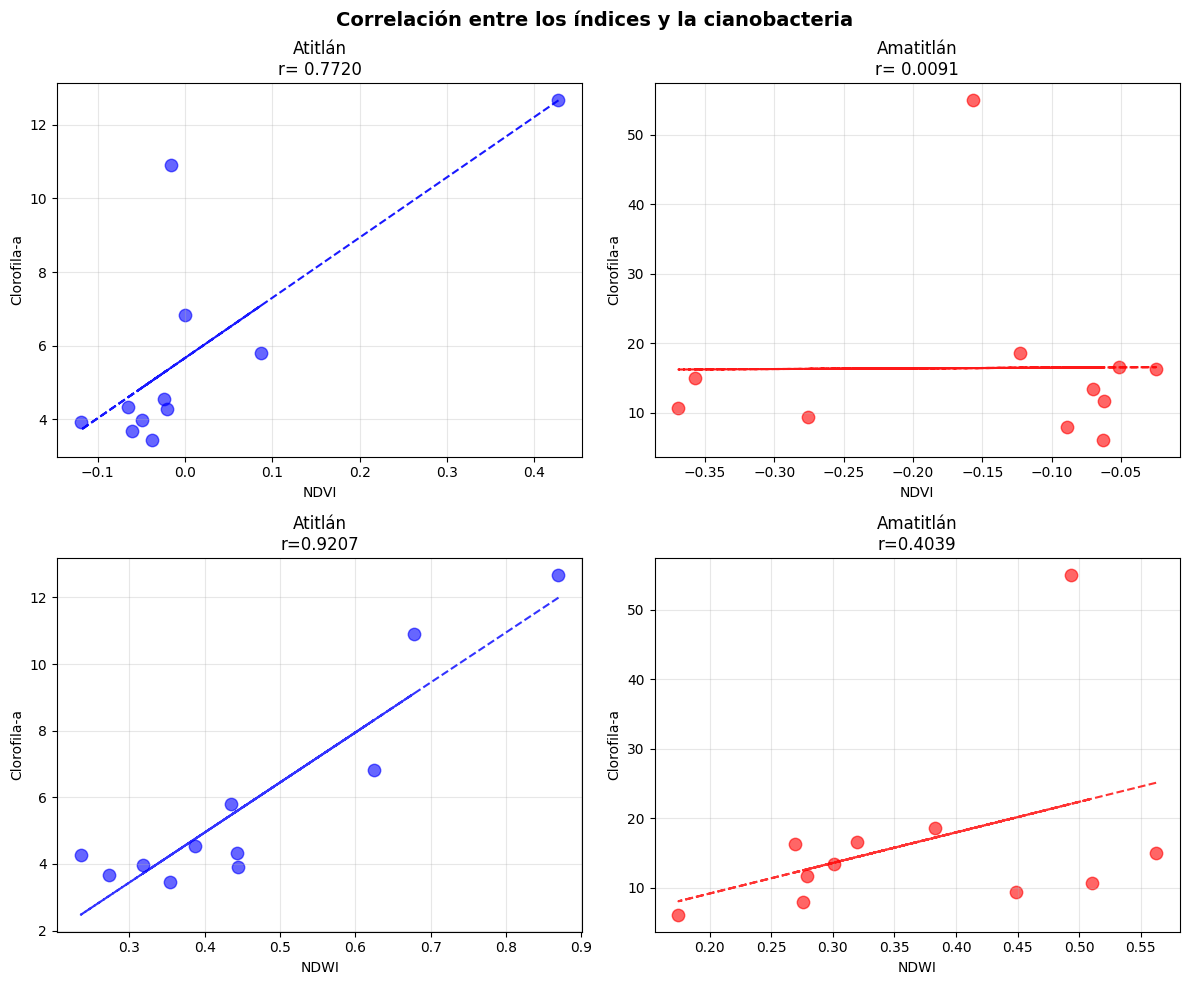

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2 , figsize = (12 , 10))
fig.suptitle('Correlación entre los índices y la cianobacteria', fontsize= 14, fontweight = 'bold')

colores = {'Atitlán': 'blue', 'Amatitlán': 'red'}

for idx_lago, lago_nombre in enumerate(lagos.keys()):
    ndvi = datos_corr[lago_nombre]['NDVI']
    ndwi = datos_corr[lago_nombre]['NDWI']
    cyano = datos_corr[lago_nombre]['CYANO']
    color = colores[lago_nombre]
    ax = axes[0, idx_lago]
    ax.scatter(ndvi, cyano , color = color, s= 80 , alpha= 0.6)
    
    z = np.polyfit(ndvi, cyano, 1)
    p = np.poly1d(z)
    ax.plot(ndvi, p(ndvi), color= color, linestyle= '--', alpha = 0.9)
    
    corr = correlaciones[lago_nombre]['NDVI_CYANO']
    ax.set_xlabel('NDVI')
    ax.set_ylabel('Clorofila-a')
    ax.set_title(f'{lago_nombre}\nr= {corr:.4f}')
    ax.grid(True,  alpha= 0.3)
    
    ax = axes[1, idx_lago]
    ax.scatter(ndwi , cyano , color= color, s= 80, alpha= 0.6)
    
    z = np.polyfit(ndwi, cyano, 1)
    p = np.poly1d(z)
    ax.plot(ndwi, p(ndwi) , color= color , linestyle= '--', alpha = 0.8)
    corr = correlaciones[lago_nombre]['NDWI_CYANO']
    ax.set_xlabel('NDWI')
    ax.set_ylabel('Clorofila-a')
    ax.set_title(f'{lago_nombre}\nr={corr:.4f}')
    ax.grid(True, alpha= 0.3)

plt.tight_layout()
plt.savefig('correlacion_indices_cyano.png', dpi=100, bbox_inches='tight')
plt.show()



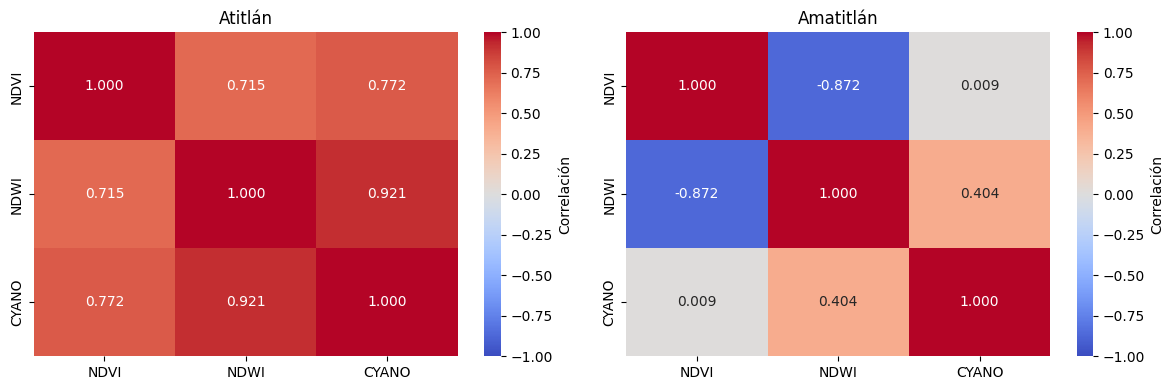

In [33]:
import seaborn as sns

fig, axes = plt.subplots(1 , 2 , figsize= (12 , 4))

for idx_lago, lago_nombre in enumerate(lagos.keys()):
    ndvi = datos_corr[lago_nombre]['NDVI']
    ndwi = datos_corr[lago_nombre]['NDWI']
    cyano = datos_corr[lago_nombre]['CYANO']
    
    data_matriz = np.column_stack([ndvi, ndwi, cyano])
    corr_matrix = np.corrcoef(data_matriz.T)
    
    ax = axes[idx_lago]
    sns.heatmap(corr_matrix, annot= True , fmt= '.3f', cmap = 'coolwarm', center= 0 , vmin= -1 , vmax= 1 , ax =ax, cbar_kws={'label': 'Correlación'} , xticklabels= ['NDVI' , 'NDWI', 'CYANO'], yticklabels= ['NDVI' , 'NDWI' , 'CYANO'])
    ax.set_title(f'{lago_nombre}')

plt.tight_layout()
plt.savefig('matriz_correlacion.png' , dpi= 100,  bbox_inches= 'tight' )
plt.show()

## 7. Análisis de los lagos y comparación entre ellos

### 7.1 Profileración de cianobacteria en el periodo, por cada lago.

In [34]:
print("7.1 ANÁLISIS DE LA PROLIFERACIÓN POR LAGO")

resumen_lagos = {}
umbral_alerta = 20  # mg/m3 de clorofila-a, referencia de alerta moderada y consideración

for lago_nombre in df_temporal['Lago'].unique():
    datos_lago = df_temporal[df_temporal['Lago'] == lago_nombre].sort_values('Fecha')

    valores = datos_lago['Promedio_CYANO'].values
    dias = (datos_lago['Fecha'] - datos_lago['Fecha'].min()).dt.days.values

    pendiente, _ = np.polyfit(dias, valores, 1)
    n_eventos = (valores > umbral_alerta).sum()

    resumen_lagos[lago_nombre] = {
        'promedio': np.mean(valores),
        'std': np.std(valores),
        'minimo': np.min(valores),
        'maximo': np.max(valores),
        'pendiente_dia': pendiente,
        'n_eventos_alerta': n_eventos,
        'pct_fechas_alerta': 100 * n_eventos / len(valores)
    }

    tendencia = "creciente" if pendiente > 0.01 else ("decreciente" if pendiente < -0.01 else "estable")

    print(f"\n{lago_nombre}:")
    print(f"  promedio del período: {np.mean(valores):.2f} mg/m3")
    print(f"  desviación estándar: {np.std(valores):.2f}")
    print(f"  rango: {np.min(valores):.2f} - {np.max(valores):.2f} mg/m3")
    print(f"  tendencia: {tendencia} ({pendiente:.4f} mg/m3 por día)")
    print(f"  fechas con nivel de alerta (>{umbral_alerta} mg/m3): {n_eventos}/{len(valores)} ({100*n_eventos/len(valores):.1f}%)")

7.1 ANÁLISIS DE LA PROLIFERACIÓN POR LAGO

Amatitlán:
  promedio del período: 16.42 mg/m3
  desviación estándar: 12.73
  rango: 6.11 - 54.96 mg/m3
  tendencia: creciente (0.0326 mg/m3 por día)
  fechas con nivel de alerta (>20 mg/m3): 1/11 (9.1%)

Atitlán:
  promedio del período: 5.85 mg/m3
  desviación estándar: 2.97
  rango: 3.44 - 12.67 mg/m3
  tendencia: estable (-0.0066 mg/m3 por día)
  fechas con nivel de alerta (>20 mg/m3): 0/11 (0.0%)


### 7.2 Compara la intensidad y la frecuencia de floraciones entre ambos lagos.

7.2 COMPARACIÓN ENTRE LAGOS: INTENSIDAD Y FRECUENCIA


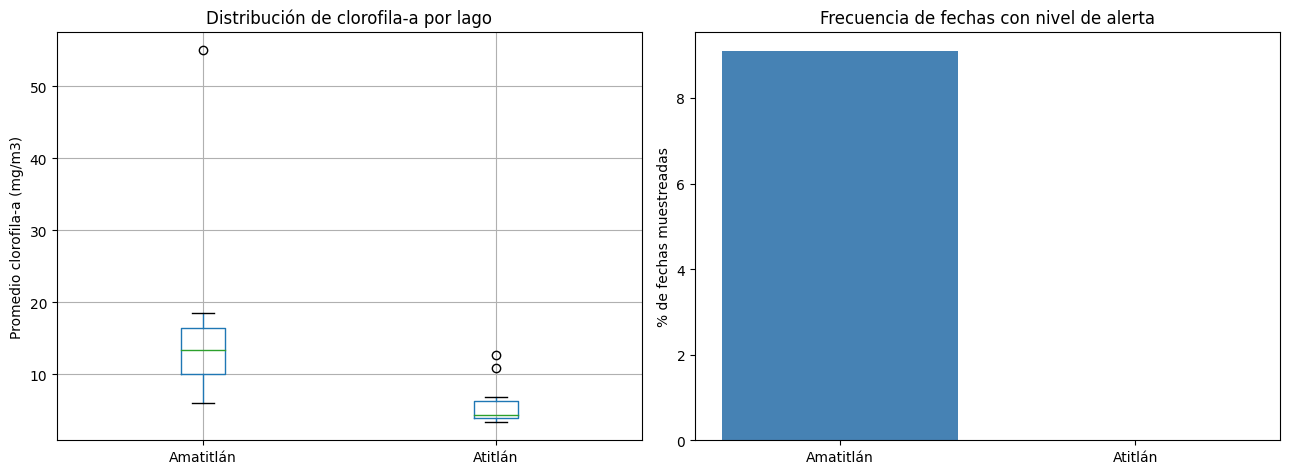


Prueba Mann-Whitney U (Atitlán vs Amatitlán):
  estadístico: 10.00
  p-value: 0.0010
  diferencia significativa (alfa=0.05)
Sí existe una diferencia entre Atitlán y Amatitlán


In [35]:
from scipy.stats import mannwhitneyu

print("7.2 COMPARACIÓN ENTRE LAGOS: INTENSIDAD Y FRECUENCIA")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_temporal.boxplot(column='Promedio_CYANO', by='Lago', ax=axes[0])
axes[0].set_title('Distribución de clorofila-a por lago')
axes[0].set_ylabel('Promedio clorofila-a (mg/m3)')
axes[0].set_xlabel('')
plt.suptitle('')

lagos_nombres = list(resumen_lagos.keys())
frecuencias = [resumen_lagos[l]['pct_fechas_alerta'] for l in lagos_nombres]
axes[1].bar(lagos_nombres, frecuencias, color=['steelblue', 'indianred'])
axes[1].set_title('Frecuencia de fechas con nivel de alerta')
axes[1].set_ylabel('% de fechas muestreadas')

plt.tight_layout()
plt.savefig('comparacion_lagos(7.2).png', dpi=150, bbox_inches='tight')
plt.show()

val_atitlan = df_temporal[df_temporal['Lago']=='Atitlán']['Promedio_CYANO']
val_amatitlan = df_temporal[df_temporal['Lago']=='Amatitlán']['Promedio_CYANO']

stat, pval = mannwhitneyu(val_atitlan, val_amatitlan, alternative='two-sided')

print(f"\nPrueba Mann-Whitney U (Atitlán vs Amatitlán):")
print(f"  estadístico: {stat:.2f}")
print(f"  p-value: {pval:.4f}")
print(f"  {'diferencia significativa' if pval < 0.05 else 'sin diferencia significativa'} (alfa=0.05)")
print("Sí existe una diferencia entre Atitlán y Amatitlán")

### 7.3 Diferencias entre causas de la cianobacteria


Luego de una breve investigación y consulta con un experto (un familiar de un integrante del grupo es Ing. Ambiental), se deterimó que la principal causa de la proliferación de cianobacterias son los asentamientos humanos a las orillas de las cuencas de los lagos. Ya que, a causa de los desechos de los mismos (de hogares e industriales), es que se asienta la basura y residuos en el fondo del lago; Amatitlán, al ser menos hondo, sufre mayor acumulación que Atitlán. Estos desechos y residuos contienen, en muchos casos, altos contenidos de fósforo y nitrógeno, los cuales forman parte del alimento principal de las cianobacterias, aumentando la velocidad de su proliferación. Es mucho más notorio y presente en el lago de Amatitlán, ya que ahí es donde se descarga todo el desecho de la ciudad capital (el punto más poblado del país, por medio del Río Villalobos); mientras que en Atitlán, la población aledaña es considerablemente menor, generando así menor desecho.  
Además, hay otros dos factores que afectan mucho a cada lago: Atitlán no tiene salida directa al mar, por lo que los nutrientes que entran, ya sea ingresados a consecuencia de actividad humana aledaña, o por algún evento meteorológico (tormenta, depresión tropical, etc.), no pueden salir fácilmente, sino que se quedan atrapados dentro de la cuenca del lago. Por otra parte, Amatitlán posee una temperatura promedio mayor, al estar más bajo que Atitlán (1188msnm vs 1560msnm), por lo que la cálida temperatura favorece más al desarrollo y proliferación veloz de las cianobacterias. 

### 7.4 Conclusiones con evidencias

In [36]:
print("7.4 TABLA RESUMEN DE EVIDENCIA")

tabla_resumen = pd.DataFrame({
    'Lago': lagos_nombres,
    'Promedio CYANO (mg/m3)': [resumen_lagos[l]['promedio'] for l in lagos_nombres],
    'Máximo (mg/m3)': [resumen_lagos[l]['maximo'] for l in lagos_nombres],
    'Tendencia (mg/m3/día)': [resumen_lagos[l]['pendiente_dia'] for l in lagos_nombres],
    '% fechas en alerta': [resumen_lagos[l]['pct_fechas_alerta'] for l in lagos_nombres],
    'Corr. NDVI-CYANO': [correlaciones[l]['NDVI_CYANO'] for l in lagos_nombres],
    'Corr. NDWI-CYANO': [correlaciones[l]['NDWI_CYANO'] for l in lagos_nombres],
})

print(tabla_resumen.round(3).to_string(index=False))
tabla_resumen.to_csv('tabla_resumen_seccion7.csv', index=False)

7.4 TABLA RESUMEN DE EVIDENCIA
     Lago  Promedio CYANO (mg/m3)  Máximo (mg/m3)  Tendencia (mg/m3/día)  % fechas en alerta  Corr. NDVI-CYANO  Corr. NDWI-CYANO
Amatitlán                  16.421          54.956                  0.033               9.091             0.009             0.404
  Atitlán                   5.848          12.670                 -0.007               0.000             0.772             0.921


## 8 Análisis exploratorio adicional
### 8.1. Evalúe la extensión espacial de la floración en cada fecha mediante el porcentaje del lago con valores altos de cianobacteria

Umbral usado: Chl-a > 20 mg/m3

     Lago      Fecha  Pct_area_alta
Amatitlán 2025-01-28      20.297778
Amatitlán 2025-04-15       5.372104
Amatitlán 2025-04-28      15.938524
Amatitlán 2025-11-24      11.428005
Amatitlán 2026-01-08      32.116439
Amatitlán 2026-02-02       0.354603
Amatitlán 2026-02-07       4.991842
Amatitlán 2026-03-29      15.542191
Amatitlán 2026-04-13      20.977138
Amatitlán 2026-04-28      32.167371
Amatitlán 2026-06-19      80.255923
  Atitlán 2025-01-18       8.247743
  Atitlán 2025-04-13       0.315967
  Atitlán 2025-05-13       0.273455
  Atitlán 2025-07-17       0.667471
  Atitlán 2025-11-21       8.437413
  Atitlán 2025-12-29       2.356978
  Atitlán 2026-02-12       2.889930
  Atitlán 2026-03-24       0.392810
  Atitlán 2026-04-13       0.324850
  Atitlán 2026-04-28       0.228718
  Atitlán 2026-07-22       0.491145


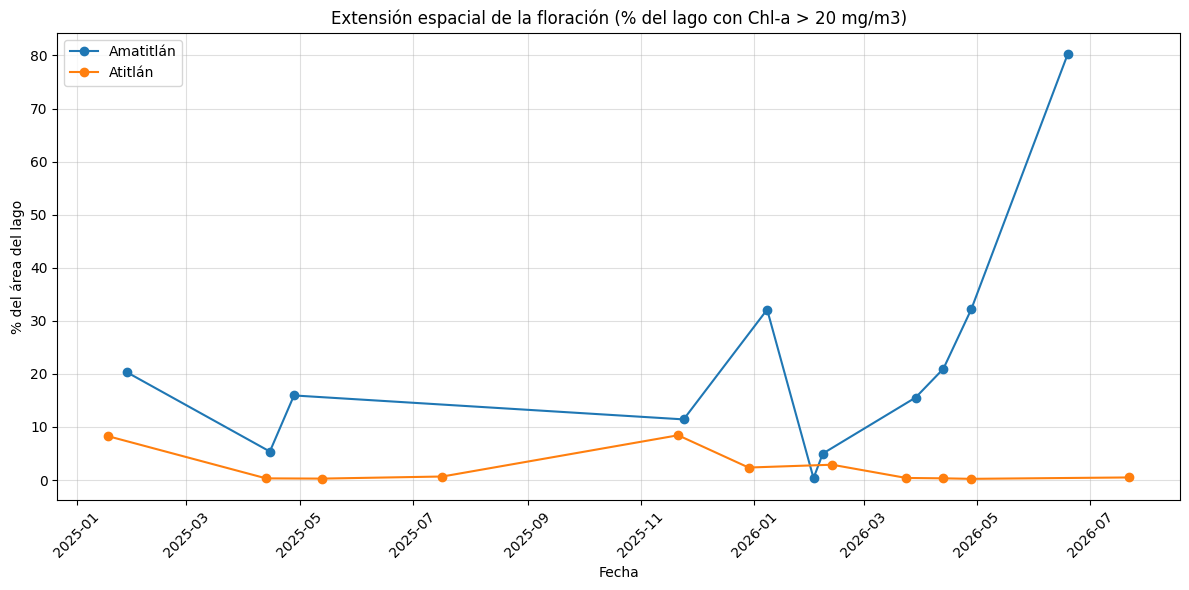


Resumen por lago:
            mean    max   min
Lago                         
Amatitlán  21.77  80.26  0.35
Atitlán     2.24   8.44  0.23


In [37]:
def pct_area_alta(lago_nombre, fecha, umbral=umbral_alerta):
    cyano = indices_calculados[lago_nombre][fecha]['CYANO']
    valido = np.isfinite(cyano)  # solo píxeles de agua
    alto = (cyano > umbral) & valido
    if valido.sum() == 0:
        return np.nan
    return 100 * alto.sum() / valido.sum()

extension_espacial = []
for lago_nombre in lagos.keys():
    for fecha in sorted(indices_calculados[lago_nombre].keys()):
        extension_espacial.append({
            'Lago': lago_nombre, 'Fecha': fecha,
            'Pct_area_alta': pct_area_alta(lago_nombre, fecha)
        })

df_extension = pd.DataFrame(extension_espacial)
df_extension['Fecha'] = pd.to_datetime(df_extension['Fecha'])
df_extension = df_extension.sort_values(['Lago', 'Fecha']).reset_index(drop=True)

print(f"Umbral usado: Chl-a > {umbral_alerta} mg/m3\n")
print(df_extension.to_string(index=False))

plt.figure(figsize=(12, 6))
for lago_nombre in df_extension['Lago'].unique():
    datos_lago = df_extension[df_extension['Lago'] == lago_nombre]
    plt.plot(datos_lago['Fecha'], datos_lago['Pct_area_alta'], marker='o', label=lago_nombre)

plt.title(f'Extensión espacial de la floración (% del lago con Chl-a > {umbral_alerta} mg/m3)')
plt.xlabel('Fecha'); plt.ylabel('% del área del lago')
plt.legend(); plt.grid(alpha=0.4); plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('extension_espacial_floracion(8.1).png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResumen por lago:")
print(df_extension.groupby('Lago')['Pct_area_alta'].agg(['mean', 'max', 'min']).round(2))

### 8.2. Identifique posibles zonas persistentes de acumulación y discuta su significado ambiental.

### 8.3. Compare la distribución de valores entre fechas mediante histogramas, boxplots o mapas de diferencia.

### 8.4. Explore si existe un patrón estacional en la proliferación observada.

### 8.5. Interprete todos los resultados y explique qué aportan al entendimiento del comportamiento de cada lago